In [1]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 489.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 285.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.0
    Unin

In [2]:
!pip install pandas pillow

In [3]:
!pip install pandas
!pip install opencv-python

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

# Set constants
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 6

# Path to dataset
dataset_path = '/kaggle/input/corn-leaf-diseases-dataset-from-bangladesh/Corn Leaf Diseases Dataset From Bangladesh'

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class Names:", class_names)

# Unified rescaling layer
rescale_layer = layers.Rescaling(1./255)

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Preprocessing function
def preprocess(ds, augment=False):
    ds = ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = preprocess(train_ds, augment=True)
val_ds = preprocess(val_ds, augment=False)

# Compute class weights safely
all_labels = []
for _, label in train_ds.unbatch():
    all_labels.append(label.numpy())
labels = np.array(all_labels)

class_weights_raw = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_raw)}
print("Class Weights:", class_weights)

# Patch creation layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Patch encoder layer
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

# MLP block
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Transformer block
def transformer_block(x, num_heads, projection_dim, transformer_units, dropout_rate):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate)(x1, x1)
    x2 = layers.Add()([attention_output, x])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp(x3, hidden_units=[transformer_units, projection_dim], dropout_rate=dropout_rate)
    return layers.Add()([x3, x2])

# Build ViT model
def build_vit_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)
    patches = Patches(PATCH_SIZE)(inputs)
    encoded_patches = PatchEncoder(NUM_PATCHES, EMBED_DIM)(patches)

    for _ in range(NUM_LAYERS):
        encoded_patches = transformer_block(encoded_patches, NUM_HEADS, EMBED_DIM, FF_DIM, dropout_rate=0.1)

    x = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = mlp(x, hidden_units=[FF_DIM], dropout_rate=0.1)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=outputs)

Found 14628 files belonging to 4 classes.
Using 11703 files for training.
Found 14628 files belonging to 4 classes.
Using 2925 files for validation.
Class Names: ['Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Leaf_Blight']
Class Weights: {0: 0.9589478859390363, 1: 1.1124524714828898, 2: 0.9880952380952381, 3: 0.9558150931068279}


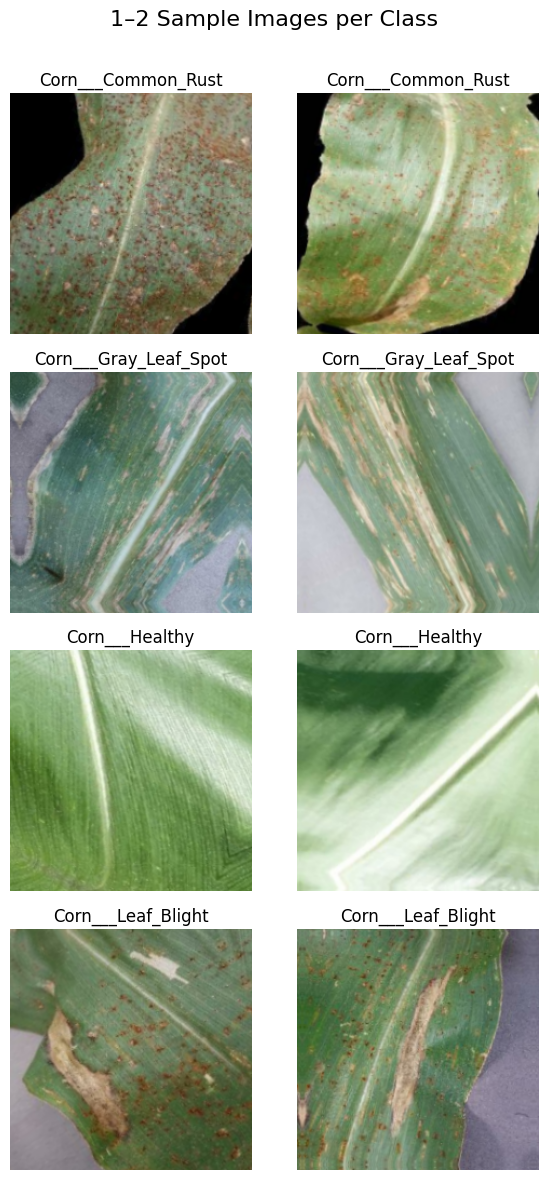

In [5]:
import matplotlib.pyplot as plt

# Build a dictionary to store 2 images per class
class_samples = {class_name: [] for class_name in class_names}

# Loop through unbatched dataset to collect samples
for image, label in train_ds.unbatch():
    class_name = class_names[label.numpy()]
    if len(class_samples[class_name]) < 2:
        class_samples[class_name].append(image)
    # Stop if we have 2 images for every class
    if all(len(imgs) == 2 for imgs in class_samples.values()):
        break

# Plot the collected samples
fig, axes = plt.subplots(len(class_names), 2, figsize=(6, 3 * len(class_names)))
fig.suptitle("1–2 Sample Images per Class", fontsize=16)

for i, class_name in enumerate(class_names):
    for j in range(2):
        ax = axes[i, j] if len(class_names) > 1 else axes[j]
        if j < len(class_samples[class_name]):
            img = (class_samples[class_name][j].numpy() * 255).astype("uint8")  # Fix here
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{class_name}")
        else:
            ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [6]:
def visualize_one_patch_per_class(dataset, class_names, patch_size):
    collected = {}

    # Unbatch if not already
    dataset = dataset.unbatch()

    for img, label in dataset:
        label = label.numpy()
        class_name = class_names[label]
        if class_name not in collected:
            collected[class_name] = img
        if len(collected) == len(class_names):
            break

    for class_name, image in collected.items():
        print(f"Class: {class_name}")
        image_disp = (image.numpy() * 255).astype("uint8")

        plt.figure(figsize=(3, 3))
        plt.imshow(image_disp)
        plt.axis("off")
        plt.title(f"Original: {class_name}")
        plt.show()

        patches_layer = Patches(patch_size)
        normalized_img = tf.expand_dims(image, axis=0)
        patches = patches_layer(normalized_img)
        print(f"{class_name} - Patches shape: {patches.shape}")

        num_patches = patches.shape[1]
        plt.figure(figsize=(4, 4))
        for i in range(min(16, num_patches)):
            patch = patches[0, i]
            patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
            patch_img = tf.clip_by_value(patch_img, 0.0, 1.0).numpy()
            plt.subplot(4, 4, i + 1)
            plt.imshow(patch_img)
            plt.axis("off")
        plt.suptitle(f"Patches: {class_name}")
        plt.tight_layout()
        plt.show()

Class: Corn___Gray_Leaf_Spot


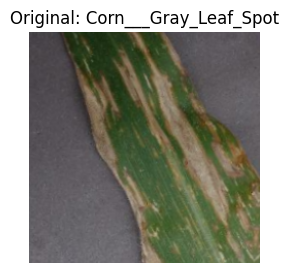

Corn___Gray_Leaf_Spot - Patches shape: (1, 196, 768)


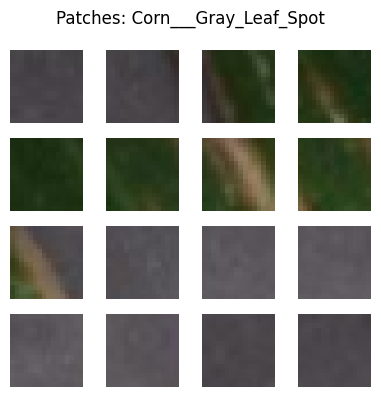

Class: Corn___Healthy


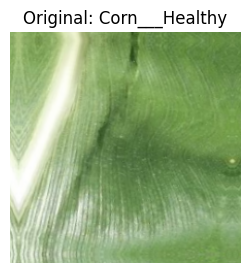

Corn___Healthy - Patches shape: (1, 196, 768)


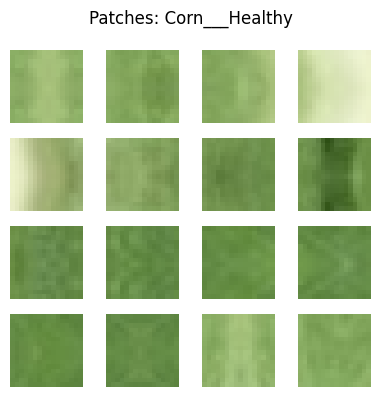

Class: Corn___Leaf_Blight


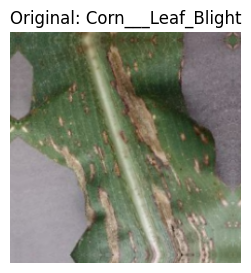

Corn___Leaf_Blight - Patches shape: (1, 196, 768)


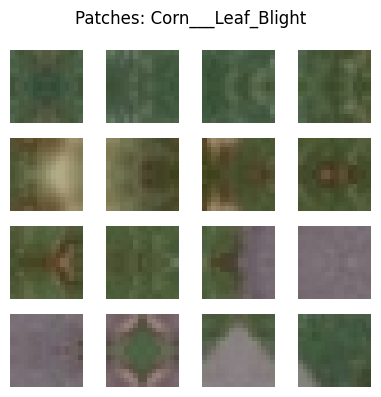

Class: Corn___Common_Rust


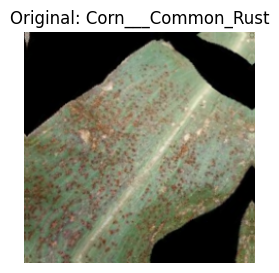

Corn___Common_Rust - Patches shape: (1, 196, 768)


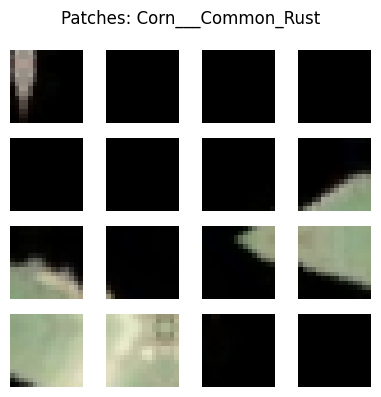

In [7]:
visualize_one_patch_per_class(train_ds, class_names, patch_size=PATCH_SIZE)

In [8]:
# Build and compile the model
vit_model = build_vit_model()
vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary
vit_model.summary()

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint("vit_model.h5", save_best_only=True)
earlystop_cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 patches_4 (Patches)            (None, None, 768)    0           ['input_1[0][0]']                
                                                                                                  
 patch_encoder (PatchEncoder)   (None, None, 64)     61760       ['patches_4[0][0]']              
                                                                                                  
 layer_normalization (LayerNorm  (None, None, 64)    128         ['patch_encoder[0][0]']      

In [9]:
# Train the model
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, earlystop_cb],
    class_weight=class_weights
)

Epoch 1/20
366/366 [==============================] - 644s 2s/step - loss: 0.4887 - accuracy: 0.7688 - val_loss: 0.3321 - val_accuracy: 0.7720
Epoch 2/20
366/366 [==============================] - 617s 2s/step - loss: 0.3319 - accuracy: 0.8507 - val_loss: 0.1990 - val_accuracy: 0.9166
Epoch 3/20
366/366 [==============================] - 617s 2s/step - loss: 0.2618 - accuracy: 0.8944 - val_loss: 0.2551 - val_accuracy: 0.9067
Epoch 4/20
366/366 [==============================] - 615s 2s/step - loss: 0.2169 - accuracy: 0.9163 - val_loss: 0.1486 - val_accuracy: 0.9491
Epoch 5/20
366/366 [==============================] - 610s 2s/step - loss: 0.1808 - accuracy: 0.9321 - val_loss: 0.1029 - val_accuracy: 0.9621
Epoch 6/20
366/366 [==============================] - 606s 2s/step - loss: 0.1559 - accuracy: 0.9401 - val_loss: 0.1741 - val_accuracy: 0.9262
Epoch 7/20
366/366 [==============================] - 602s 2s/step - loss: 0.1349 - accuracy: 0.9496 - val_loss: 0.0746 - val_accuracy: 0.9771

In [10]:
# Evaluate the model
loss, accuracy = vit_model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

92/92 [==============================] - 44s 476ms/step - loss: 0.0530 - accuracy: 0.9836
Validation Accuracy: 98.36%


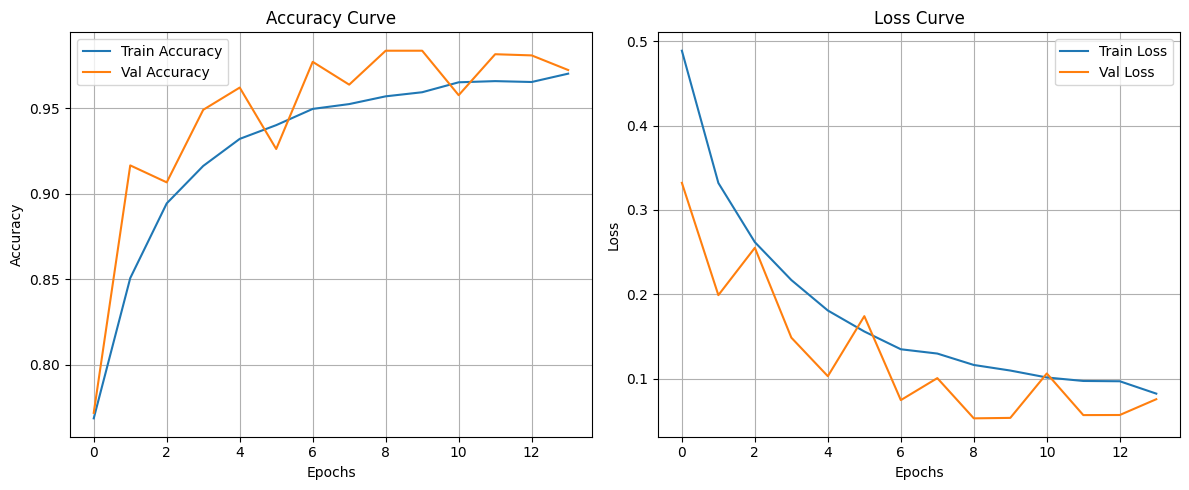

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axs[0].plot(history.history["accuracy"], label="Train Accuracy")
axs[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[0].set_title("Accuracy Curve")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].legend()
axs[0].grid(True)

# Loss plot
axs[1].plot(history.history["loss"], label="Train Loss")
axs[1].plot(history.history["val_loss"], label="Val Loss")
axs[1].set_title("Loss Curve")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
#Evaluate
true_labels = []
pred_labels = []

for images, labels in val_ds:
    preds = vit_model.predict(images)
    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(preds, axis=1))

1/1 [==============================] - 1s 1s/step


Classification Report:
                        precision    recall  f1-score   support

   Corn___Common_Rust       1.00      1.00      1.00       763
Corn___Gray_Leaf_Spot       0.96      0.98      0.97       654
       Corn___Healthy       0.99      1.00      1.00       753
   Corn___Leaf_Blight       0.98      0.96      0.97       755

             accuracy                           0.98      2925
            macro avg       0.98      0.98      0.98      2925
         weighted avg       0.98      0.98      0.98      2925



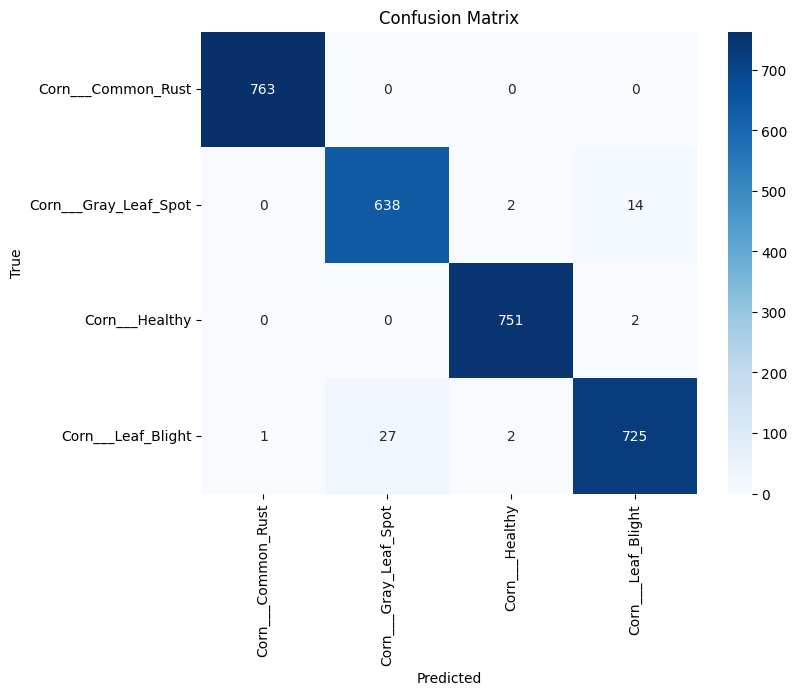

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vit_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names)

# Print classification report
print("Classification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

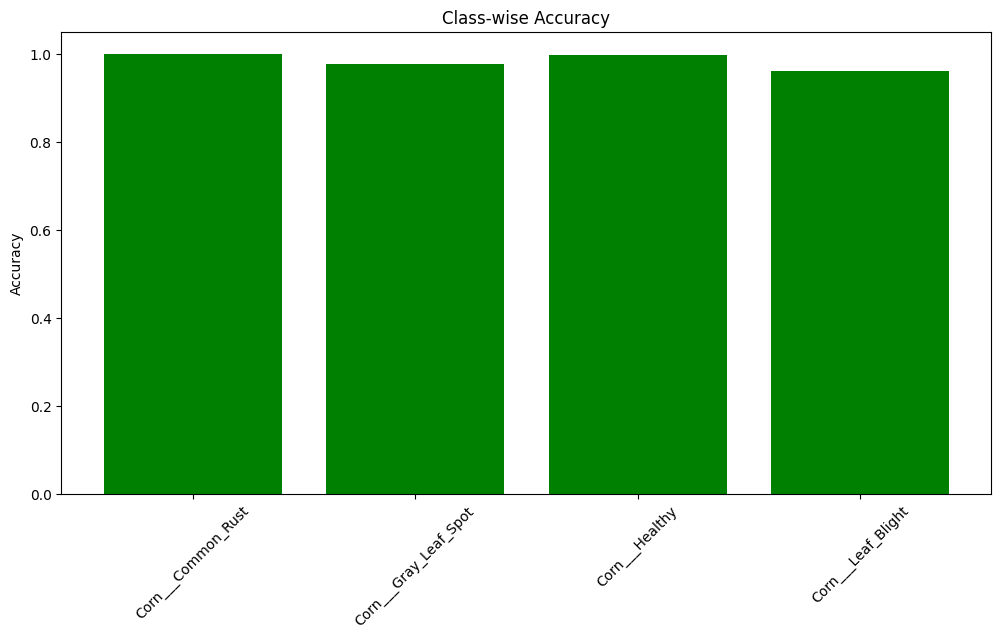

In [14]:
# Class-wise Accuracy Visualization
class_counts = dict.fromkeys(class_names, 0)
correct_counts = dict.fromkeys(class_names, 0)

for true, pred in zip(true_labels, pred_labels):
    class_counts[class_names[true]] += 1
    if true == pred:
        correct_counts[class_names[true]] += 1

classwise_acc = {cls: correct_counts[cls]/class_counts[cls] for cls in class_names}

plt.figure(figsize=(12, 6))
plt.bar(classwise_acc.keys(), classwise_acc.values(), color='green')
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.show()

In [15]:
# Test with New Image

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)
    predictions = vit_model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(tf.nn.softmax(predictions))
    print(f"Predicted: {predicted_class} ({confidence:.2%})")